# Notebook 4: Attention Mechanisms for Proteins

**Objective:** Master the attention mechanisms used in AlphaFold2 -- from standard self-attention to the specialized row, column, triangular, and gated variants.

---

AlphaFold2 does not simply apply vanilla Transformers to protein sequences. Instead, it engineers a suite of **specialized attention mechanisms** that respect the two-dimensional structure of multiple sequence alignments (MSAs) and pair representations. This notebook builds each variant from scratch, grounding every operation in precise linear algebra and visualizing the resulting attention patterns.

**Prerequisites:** Familiarity with linear algebra, softmax, and basic neural network operations.

**Dependencies:** `numpy`, `matplotlib`

### Roadmap

| Section | Topic | Key Idea |
|---------|-------|----------|
| 1 | Self-Attention from Scratch | Scaled dot-product attention |
| 2 | Multi-Head Attention | Parallel attention subspaces |
| 3 | Row-wise (Axial) Attention on MSAs | Per-sequence residue attention with pair bias |
| 4 | Column-wise Attention on MSAs | Per-position sequence attention |
| 5 | Gated Self-Attention | Sigmoid gating of attention output |
| 6 | Triangular Self-Attention | Attention on pair representations |
| 7 | Computational Complexity Comparison | Scaling analysis |
| 8 | Summary and Key Takeaways | Synthesis and preview |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 16
})

np.random.seed(42)
print('Environment ready.')

Environment ready.


---

## 1. Self-Attention from Scratch

The fundamental building block of all Transformer-based architectures is **scaled dot-product attention**. Given an input sequence of $n$ vectors, each of dimension $d$, we represent the input as a matrix:

$$\mathbf{X} \in \mathbb{R}^{n \times d}$$

We learn three linear projections that map each input vector into a **query**, **key**, and **value**:

$$\mathbf{Q} = \mathbf{X}\mathbf{W}_Q, \quad \mathbf{K} = \mathbf{X}\mathbf{W}_K, \quad \mathbf{V} = \mathbf{X}\mathbf{W}_V$$

where $\mathbf{W}_Q, \mathbf{W}_K \in \mathbb{R}^{d \times d_k}$ and $\mathbf{W}_V \in \mathbb{R}^{d \times d_v}$.

The attention output is then computed as:

$$\text{Attn}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right)\mathbf{V}$$

### Why scale by $\sqrt{d_k}$?

Without scaling, the dot products $\mathbf{Q}\mathbf{K}^T$ grow in magnitude with $d_k$. If $q_i$ and $k_j$ are independent random variables with zero mean and unit variance, then:

$$\text{Var}(q_i^T k_j) = \sum_{l=1}^{d_k} \text{Var}(q_{il} \cdot k_{jl}) = d_k$$

The standard deviation is $\sqrt{d_k}$, so dividing by this factor normalizes the logits to have unit variance, keeping the softmax in a well-conditioned regime where gradients are informative.

In [2]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    """
    Scaled dot-product attention.
    
    Parameters
    ----------
    Q : ndarray, shape (n, d_k)
    K : ndarray, shape (n, d_k)
    V : ndarray, shape (n, d_v)
    
    Returns
    -------
    output : ndarray, shape (n, d_v)
    weights : ndarray, shape (n, n)  -- the attention weight matrix
    """
    d_k = Q.shape[-1]
    # Compute raw attention logits
    logits = Q @ K.T / np.sqrt(d_k)          # (n, n)
    # Apply softmax row-wise
    weights = softmax(logits, axis=-1)         # (n, n)
    # Weighted combination of values
    output = weights @ V                       # (n, d_v)
    return output, weights


# ----- Synthetic input -----
n_tokens = 8
d_model = 16
d_k = d_v = 16

X = np.random.randn(n_tokens, d_model)

# Learned projection matrices (randomly initialized)
W_Q = np.random.randn(d_model, d_k) * 0.1
W_K = np.random.randn(d_model, d_k) * 0.1
W_V = np.random.randn(d_model, d_v) * 0.1

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f'Input X shape:           {X.shape}')
print(f'Q, K shapes:             {Q.shape}, {K.shape}')
print(f'V shape:                 {V.shape}')
print(f'Attention weights shape:  {attn_weights.shape}')
print(f'Output shape:            {output.shape}')
print(f'\nRow sums of attention weights (should be 1.0):')
print(np.round(attn_weights.sum(axis=-1), 6))

Input X shape:           (8, 16)
Q, K shapes:             (8, 16), (8, 16)
V shape:                 (8, 16)
Attention weights shape:  (8, 8)
Output shape:            (8, 16)

Row sums of attention weights (should be 1.0):
[1. 1. 1. 1. 1. 1. 1. 1.]


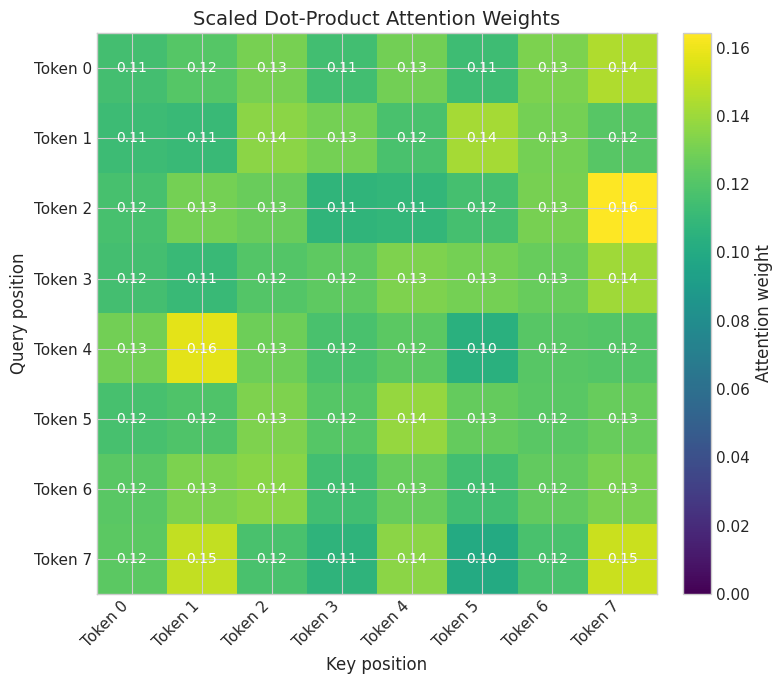

In [3]:
# Visualize the attention weight matrix
fig, ax = plt.subplots(figsize=(8, 7))

token_labels = [f'Token {i}' for i in range(n_tokens)]
im = ax.imshow(attn_weights, cmap='viridis', aspect='equal', vmin=0, vmax=attn_weights.max())
ax.set_xticks(range(n_tokens))
ax.set_yticks(range(n_tokens))
ax.set_xticklabels(token_labels, rotation=45, ha='right')
ax.set_yticklabels(token_labels)
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
ax.set_title('Scaled Dot-Product Attention Weights')

# Annotate cells
for i in range(n_tokens):
    for j in range(n_tokens):
        ax.text(j, i, f'{attn_weights[i, j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if attn_weights[i, j] > 0.5 * attn_weights.max() else 'black')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Attention weight')
plt.tight_layout()
plt.show()

**Interpretation:** Each row of the attention matrix is a probability distribution over key positions. The $(i,j)$ entry tells us how much token $i$ (as a query) attends to token $j$ (as a key). With random weights, the distribution is relatively uniform; after training, the model would learn to place high weight on structurally relevant positions.

---

## 2. Multi-Head Attention

A single attention head can only capture one type of relationship. **Multi-head attention (MHA)** runs $h$ attention functions in parallel, each with its own learned projections, allowing the model to jointly attend to information from different representation subspaces.

Given $h$ heads, we split the key dimension: $d_k^{\text{head}} = d_k / h$. Each head operates on its own subspace:

$$\text{head}_i = \text{Attn}(\mathbf{Q}_i, \mathbf{K}_i, \mathbf{V}_i), \quad i = 1, \dots, h$$

where $\mathbf{Q}_i = \mathbf{X}\mathbf{W}_Q^{(i)}$, $\mathbf{K}_i = \mathbf{X}\mathbf{W}_K^{(i)}$, $\mathbf{V}_i = \mathbf{X}\mathbf{W}_V^{(i)}$ with $\mathbf{W}_Q^{(i)}, \mathbf{W}_K^{(i)} \in \mathbb{R}^{d \times d_k/h}$ and $\mathbf{W}_V^{(i)} \in \mathbb{R}^{d \times d_v/h}$.

The heads are concatenated and linearly projected:

$$\text{MHA}(\mathbf{X}) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,\mathbf{W}_O$$

where $\mathbf{W}_O \in \mathbb{R}^{d_v \times d_{\text{model}}}$.

The total computational cost is the same as single-head attention with full dimensionality, since each head operates on a $d/h$-dimensional slice.

In [4]:
def multi_head_attention(X, n_heads, d_model):
    """
    Multi-head attention from scratch.
    
    Parameters
    ----------
    X : ndarray, shape (n, d_model)
    n_heads : int
    d_model : int
    
    Returns
    -------
    output : ndarray, shape (n, d_model)
    all_weights : list of ndarray, each shape (n, n)
    """
    assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
    d_head = d_model // n_heads
    n = X.shape[0]
    
    head_outputs = []
    all_weights = []
    
    for h in range(n_heads):
        # Each head has its own projection matrices
        W_Q_h = np.random.randn(d_model, d_head) * 0.1
        W_K_h = np.random.randn(d_model, d_head) * 0.1
        W_V_h = np.random.randn(d_model, d_head) * 0.1
        
        Q_h = X @ W_Q_h    # (n, d_head)
        K_h = X @ W_K_h    # (n, d_head)
        V_h = X @ W_V_h    # (n, d_head)
        
        out_h, w_h = scaled_dot_product_attention(Q_h, K_h, V_h)
        head_outputs.append(out_h)
        all_weights.append(w_h)
    
    # Concatenate heads: (n, d_model)
    concat = np.concatenate(head_outputs, axis=-1)
    
    # Output projection
    W_O = np.random.randn(d_model, d_model) * 0.1
    output = concat @ W_O
    
    return output, all_weights


# Run multi-head attention
n_heads = 4
np.random.seed(7)
X_mha = np.random.randn(n_tokens, d_model)
mha_output, head_weights = multi_head_attention(X_mha, n_heads, d_model)

print(f'Input shape:        {X_mha.shape}')
print(f'MHA output shape:   {mha_output.shape}')
print(f'Number of heads:    {len(head_weights)}')
print(f'Each head weights:  {head_weights[0].shape}')

Input shape:        (8, 16)
MHA output shape:   (8, 16)
Number of heads:    4
Each head weights:  (8, 8)


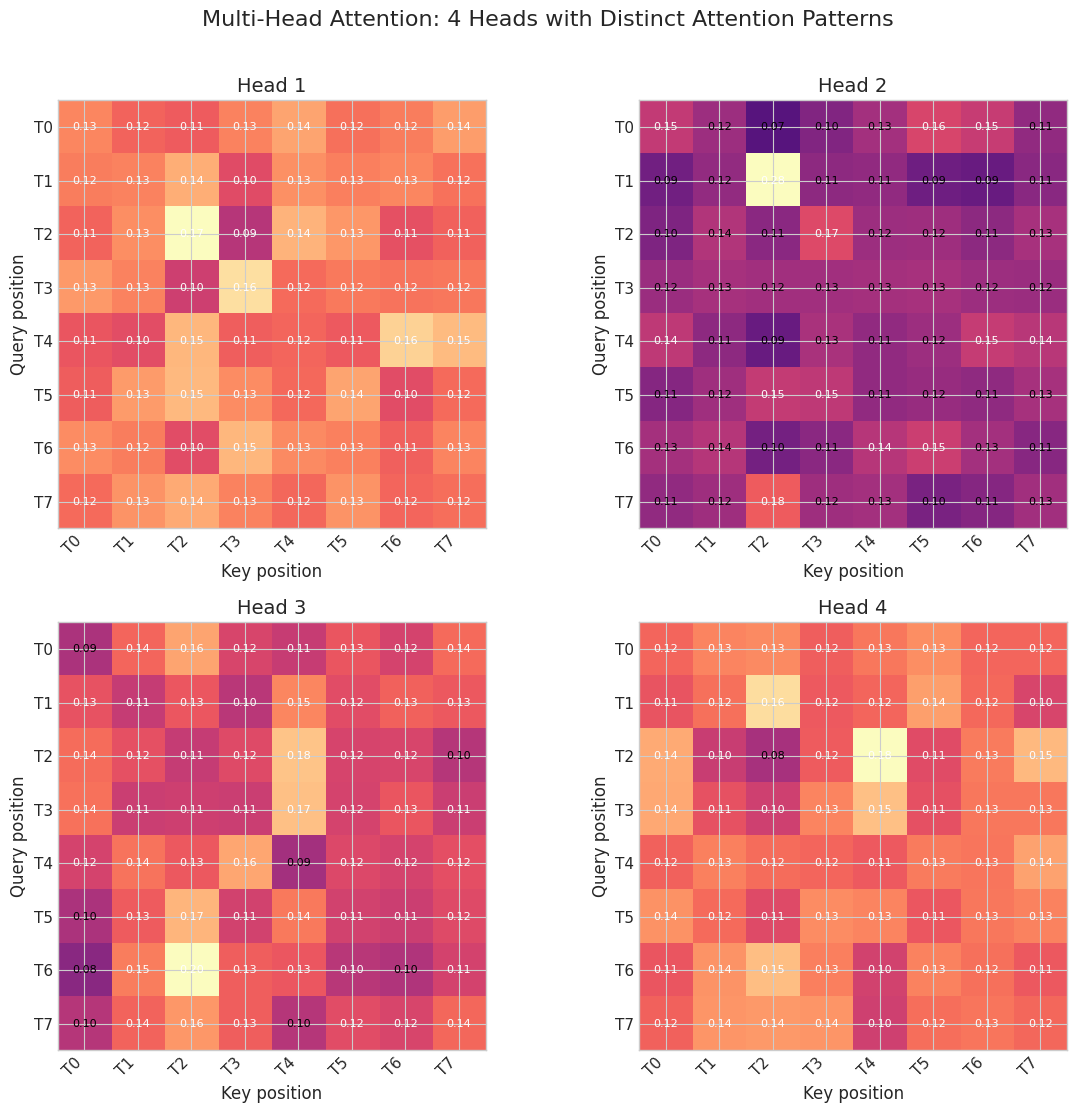

In [5]:
# Visualize all 4 attention heads side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.ravel()

for h in range(n_heads):
    ax = axes[h]
    im = ax.imshow(head_weights[h], cmap='magma', aspect='equal', vmin=0)
    ax.set_xticks(range(n_tokens))
    ax.set_yticks(range(n_tokens))
    ax.set_xticklabels([f'T{i}' for i in range(n_tokens)], rotation=45, ha='right')
    ax.set_yticklabels([f'T{i}' for i in range(n_tokens)])
    ax.set_title(f'Head {h + 1}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    
    # Annotate cells
    for i in range(n_tokens):
        for j in range(n_tokens):
            val = head_weights[h][i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if val > 0.5 * head_weights[h].max() else 'black')

fig.suptitle('Multi-Head Attention: 4 Heads with Distinct Attention Patterns', y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Each head learns (or, with random initialization, exhibits) a **different attention pattern**. In a trained model, different heads might specialize: one head might attend to local neighbors, another to distant contacts, a third to conserved positions in an alignment, etc. This diversity is exactly what allows multi-head attention to capture complex relational structure.

---

## 3. Row-wise (Axial) Attention on MSAs

A multiple sequence alignment (MSA) is naturally a **2D object**: we have $N_{\text{seq}}$ sequences, each with $N_{\text{res}}$ residue positions, and each position has an embedding of dimension $c_m$. The MSA representation is therefore:

$$\mathbf{M} \in \mathbb{R}^{N_{\text{seq}} \times N_{\text{res}} \times c_m}$$

Applying standard self-attention over all $N_{\text{seq}} \cdot N_{\text{res}}$ tokens would cost $O(N_{\text{seq}}^2 \cdot N_{\text{res}}^2)$ -- prohibitively expensive.

### Axial decomposition

AlphaFold2 decomposes attention along the two axes independently:

- **Row attention:** For each sequence $i$, attend along the **residue dimension** (positions 1 to $N_{\text{res}}$). This has complexity $O(N_{\text{seq}} \cdot N_{\text{res}}^2)$.
- **Column attention:** For each position $j$, attend along the **sequence dimension** (sequences 1 to $N_{\text{seq}}$). This has complexity $O(N_{\text{seq}}^2 \cdot N_{\text{res}})$.

### Row attention with pair bias

For each sequence $i$, the row attention operates on the slice $\mathbf{M}_{i,:} \in \mathbb{R}^{N_{\text{res}} \times c_m}$:

$$\text{RowAttn}(\mathbf{M}_{i,:}) = \text{softmax}\!\left(\frac{\mathbf{Q}_i \mathbf{K}_i^T}{\sqrt{d_k}} + \mathbf{B}\right) \mathbf{V}_i$$

where $\mathbf{Q}_i = \mathbf{M}_{i,:}\mathbf{W}_Q$, $\mathbf{K}_i = \mathbf{M}_{i,:}\mathbf{W}_K$, $\mathbf{V}_i = \mathbf{M}_{i,:}\mathbf{W}_V$.

The **key innovation** is the pair bias term $\mathbf{B} \in \mathbb{R}^{N_{\text{res}} \times N_{\text{res}}}$, which injects information from the pair representation $\mathbf{z}$ into the MSA attention:

$$B_{jk} = \text{Linear}(\mathbf{z}_{jk})$$

This pair bias is **shared across all sequences** in the MSA, providing a consistent structural prior: if residues $j$ and $k$ are known to be close (from the pair representation), the model can boost their mutual attention across all sequences simultaneously.

In [6]:
def row_attention(M, W_Q, W_K, W_V, pair_bias=None):
    """
    Row-wise attention on an MSA representation.
    
    For each sequence i, attend along the residue dimension.
    
    Parameters
    ----------
    M : ndarray, shape (N_seq, N_res, c_m)
    W_Q, W_K, W_V : ndarray, shape (c_m, d_k)
    pair_bias : ndarray or None, shape (N_res, N_res)
        Bias from pair representation, added to attention logits.
    
    Returns
    -------
    output : ndarray, shape (N_seq, N_res, d_v)
    all_weights : ndarray, shape (N_seq, N_res, N_res)
    """
    N_seq, N_res, c_m = M.shape
    d_k = W_Q.shape[1]
    
    output = np.zeros((N_seq, N_res, W_V.shape[1]))
    all_weights = np.zeros((N_seq, N_res, N_res))
    
    for i in range(N_seq):
        Q_i = M[i] @ W_Q    # (N_res, d_k)
        K_i = M[i] @ W_K    # (N_res, d_k)
        V_i = M[i] @ W_V    # (N_res, d_v)
        
        logits = Q_i @ K_i.T / np.sqrt(d_k)    # (N_res, N_res)
        
        if pair_bias is not None:
            logits = logits + pair_bias
        
        weights = softmax(logits, axis=-1)
        output[i] = weights @ V_i
        all_weights[i] = weights
    
    return output, all_weights


# --- Synthetic MSA ---
np.random.seed(21)
N_seq = 10
N_res = 20
c_m = 32
d_k_row = 16

# Random MSA representation
M = np.random.randn(N_seq, N_res, c_m) * 0.5

# Projection matrices
W_Q_row = np.random.randn(c_m, d_k_row) * 0.1
W_K_row = np.random.randn(c_m, d_k_row) * 0.1
W_V_row = np.random.randn(c_m, d_k_row) * 0.1

# --- Pair bias ---
# Simulate pair representation: z_{jk} in R^{c_z}
c_z = 16
Z_pair = np.random.randn(N_res, N_res, c_z) * 0.3
# Make it roughly symmetric (pair distances are symmetric)
Z_pair = 0.5 * (Z_pair + Z_pair.transpose(1, 0, 2))
# Linear projection to scalar bias
w_bias = np.random.randn(c_z) * 0.2
pair_bias = Z_pair @ w_bias    # (N_res, N_res)

# --- Run with and without pair bias ---
output_no_bias, weights_no_bias = row_attention(M, W_Q_row, W_K_row, W_V_row, pair_bias=None)
output_with_bias, weights_with_bias = row_attention(M, W_Q_row, W_K_row, W_V_row, pair_bias=pair_bias)

print(f'MSA shape:             {M.shape}')
print(f'Row attention output:  {output_with_bias.shape}')
print(f'Attention weights:     {weights_with_bias.shape}')

MSA shape:             (10, 20, 32)
Row attention output:  (10, 20, 16)
Attention weights:     (10, 20, 20)


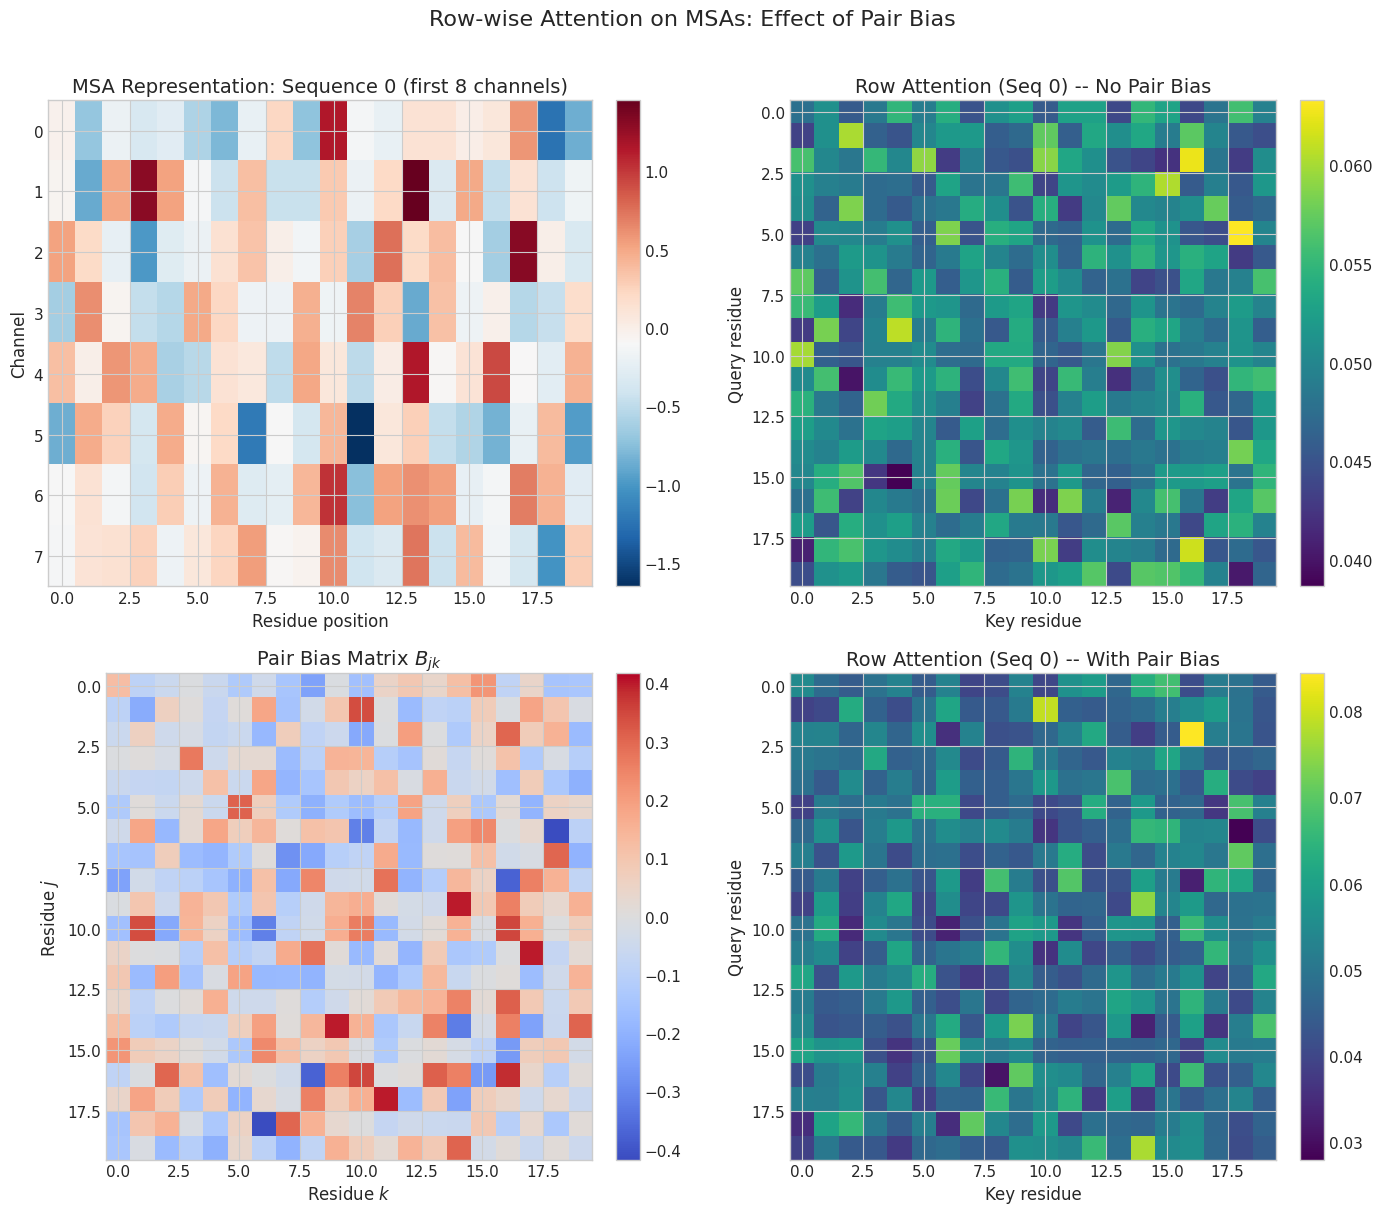

In [7]:
# Visualize: MSA slice, attention maps (with/without pair bias), pair bias matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# (a) Original MSA slice -- first 5 channels of sequence 0
ax = axes[0, 0]
im0 = ax.imshow(M[0, :, :8].T, cmap='RdBu_r', aspect='auto')
ax.set_xlabel('Residue position')
ax.set_ylabel('Channel')
ax.set_title('MSA Representation: Sequence 0 (first 8 channels)')
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# (b) Attention map without pair bias (sequence 0)
ax = axes[0, 1]
im1 = ax.imshow(weights_no_bias[0], cmap='viridis', aspect='equal')
ax.set_xlabel('Key residue')
ax.set_ylabel('Query residue')
ax.set_title('Row Attention (Seq 0) -- No Pair Bias')
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# (c) Pair bias matrix
ax = axes[1, 0]
im2 = ax.imshow(pair_bias, cmap='coolwarm', aspect='equal',
                norm=Normalize(vmin=-np.abs(pair_bias).max(), vmax=np.abs(pair_bias).max()))
ax.set_xlabel('Residue $k$')
ax.set_ylabel('Residue $j$')
ax.set_title('Pair Bias Matrix $B_{jk}$')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (d) Attention map with pair bias (sequence 0)
ax = axes[1, 1]
im3 = ax.imshow(weights_with_bias[0], cmap='viridis', aspect='equal')
ax.set_xlabel('Key residue')
ax.set_ylabel('Query residue')
ax.set_title('Row Attention (Seq 0) -- With Pair Bias')
fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Row-wise Attention on MSAs: Effect of Pair Bias', y=1.01)
plt.tight_layout()
plt.show()

**Key observations:**

1. Without pair bias, row attention relies purely on the MSA content to determine which residues attend to each other.
2. The pair bias matrix $B_{jk}$ provides a **structural prior** derived from the pair representation. Positive entries encourage attention between residue pairs that the model believes are structurally related.
3. With pair bias, the attention pattern becomes **less uniform** -- the model is guided toward residue pairs that are likely in spatial proximity, a critical inductive bias for protein structure prediction.

---

## 4. Column-wise Attention on MSAs

While row attention lets residues within a single sequence communicate, **column attention** lets the same residue position communicate **across different sequences** in the MSA.

For each position $j$, we extract the column slice $\mathbf{M}_{:,j} \in \mathbb{R}^{N_{\text{seq}} \times c_m}$ and apply attention:

$$\text{ColAttn}(\mathbf{M}_{:,j}) = \text{softmax}\!\left(\frac{\mathbf{Q}_j \mathbf{K}_j^T}{\sqrt{d_k}}\right) \mathbf{V}_j$$

where $\mathbf{Q}_j = \mathbf{M}_{:,j}\mathbf{W}_Q$, $\mathbf{K}_j = \mathbf{M}_{:,j}\mathbf{W}_K$, $\mathbf{V}_j = \mathbf{M}_{:,j}\mathbf{W}_V$.

**Complexity:** $O(N_{\text{seq}}^2 \cdot N_{\text{res}})$ -- linear in the number of residues.

### Biological motivation

Column attention captures **coevolutionary signals**. If two sequences have evolved similar amino acid patterns at position $j$, column attention learns to weight those sequences more heavily when updating the representation at position $j$. This is analogous to the information extracted by coevolution-based methods (e.g., direct coupling analysis), but learned end-to-end.

In [8]:
def column_attention(M, W_Q, W_K, W_V):
    """
    Column-wise attention on an MSA representation.
    
    For each residue position j, attend along the sequence dimension.
    
    Parameters
    ----------
    M : ndarray, shape (N_seq, N_res, c_m)
    W_Q, W_K, W_V : ndarray, shape (c_m, d_k)
    
    Returns
    -------
    output : ndarray, shape (N_seq, N_res, d_v)
    all_weights : ndarray, shape (N_res, N_seq, N_seq)
    """
    N_seq, N_res, c_m = M.shape
    d_k = W_Q.shape[1]
    d_v = W_V.shape[1]
    
    output = np.zeros((N_seq, N_res, d_v))
    all_weights = np.zeros((N_res, N_seq, N_seq))
    
    for j in range(N_res):
        col = M[:, j, :]        # (N_seq, c_m)
        Q_j = col @ W_Q         # (N_seq, d_k)
        K_j = col @ W_K         # (N_seq, d_k)
        V_j = col @ W_V         # (N_seq, d_v)
        
        logits = Q_j @ K_j.T / np.sqrt(d_k)   # (N_seq, N_seq)
        weights = softmax(logits, axis=-1)
        
        output[:, j, :] = weights @ V_j
        all_weights[j] = weights
    
    return output, all_weights


# Run column attention
np.random.seed(33)
W_Q_col = np.random.randn(c_m, d_k_row) * 0.1
W_K_col = np.random.randn(c_m, d_k_row) * 0.1
W_V_col = np.random.randn(c_m, d_k_row) * 0.1

col_output, col_weights = column_attention(M, W_Q_col, W_K_col, W_V_col)

print(f'Column attention output: {col_output.shape}')
print(f'Column weights shape:    {col_weights.shape}  (N_res, N_seq, N_seq)')

Column attention output: (10, 20, 16)
Column weights shape:    (20, 10, 10)  (N_res, N_seq, N_seq)


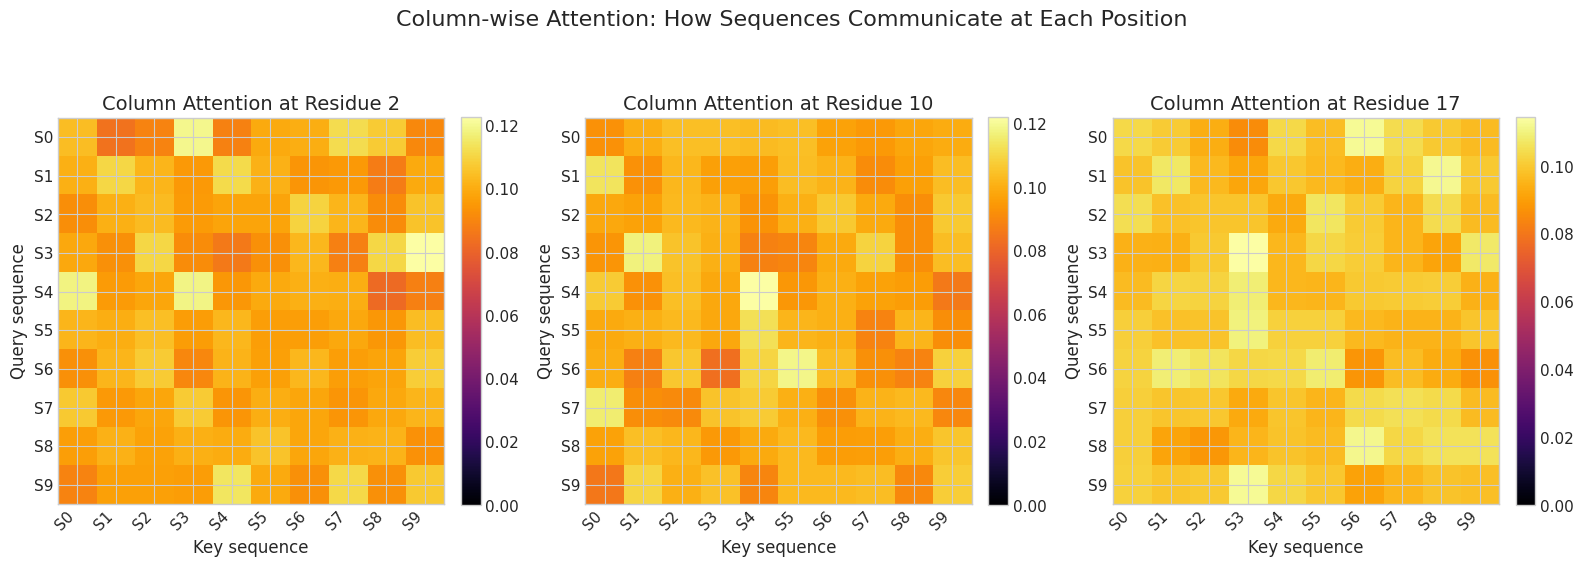

In [9]:
# Visualize column attention maps for 3 different residue positions
positions = [2, 10, 17]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

seq_labels = [f'Seq {i}' for i in range(N_seq)]

for idx, pos in enumerate(positions):
    ax = axes[idx]
    im = ax.imshow(col_weights[pos], cmap='inferno', aspect='equal', vmin=0)
    ax.set_xticks(range(N_seq))
    ax.set_yticks(range(N_seq))
    ax.set_xticklabels([f'S{i}' for i in range(N_seq)], rotation=45, ha='right')
    ax.set_yticklabels([f'S{i}' for i in range(N_seq)])
    ax.set_xlabel('Key sequence')
    ax.set_ylabel('Query sequence')
    ax.set_title(f'Column Attention at Residue {pos}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Column-wise Attention: How Sequences Communicate at Each Position', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Each panel shows which sequences attend to which at a particular residue position. Notice the patterns differ across positions -- at a conserved position, all sequences might attend roughly uniformly, while at a variable position, the attention could be more selective, grouping sequences with similar amino acid identities.

Together, **row attention** (intra-sequence, inter-residue) and **column attention** (inter-sequence, intra-residue) provide a factored approximation to full 2D attention on the MSA, reducing the complexity from $O(N_{\text{seq}}^2 N_{\text{res}}^2)$ to $O(N_{\text{seq}} N_{\text{res}}^2 + N_{\text{seq}}^2 N_{\text{res}})$.

---

## 5. Gated Self-Attention

AlphaFold2 augments its attention mechanisms with **gating**. The idea is simple but powerful: the output of the attention operation is element-wise multiplied by a learned gate, allowing the network to selectively suppress or amplify attention outputs per dimension.

Formally, gated self-attention computes:

$$\text{GatedAttn}(\mathbf{X}) = \sigma(\mathbf{X}\mathbf{W}_g + \mathbf{b}_g) \odot \text{MHA}(\mathbf{X})$$

where:
- $\mathbf{W}_g \in \mathbb{R}^{d \times d}$ and $\mathbf{b}_g \in \mathbb{R}^d$ are learned gate parameters
- $\sigma(\cdot)$ is the element-wise sigmoid function: $\sigma(x) = \frac{1}{1 + e^{-x}}$
- $\odot$ denotes the Hadamard (element-wise) product

### Why gating?

Gating provides **per-dimension, input-dependent control** over the information flow. Consider that MHA produces a $d$-dimensional output for each token. The gate vector, also $d$-dimensional and in $[0, 1]^d$, can:

- **Zero out** dimensions that are irrelevant for the current input (gate $\approx 0$)
- **Pass through** dimensions that are informative (gate $\approx 1$)

This is reminiscent of LSTM/GRU gating and helps with training stability and gradient flow in deep networks.

In [10]:
def sigmoid(x):
    """Numerically stable sigmoid."""
    return np.where(x >= 0,
                    1.0 / (1.0 + np.exp(-x)),
                    np.exp(x) / (1.0 + np.exp(x)))


def gated_self_attention(X, n_heads, d_model):
    """
    Gated multi-head self-attention.
    
    Parameters
    ----------
    X : ndarray, shape (n, d_model)
    n_heads : int
    d_model : int
    
    Returns
    -------
    gated_output : ndarray, shape (n, d_model)
    mha_output : ndarray, shape (n, d_model)
    gate_values : ndarray, shape (n, d_model)
    head_weights : list of ndarray
    """
    # Multi-head attention
    mha_output, head_weights = multi_head_attention(X, n_heads, d_model)
    
    # Gate computation
    W_g = np.random.randn(d_model, d_model) * 0.1
    b_g = np.random.randn(d_model) * 0.1
    gate_values = sigmoid(X @ W_g + b_g)    # (n, d_model)
    
    # Apply gate
    gated_output = gate_values * mha_output  # element-wise
    
    return gated_output, mha_output, gate_values, head_weights


# Run gated attention
np.random.seed(55)
X_gated = np.random.randn(n_tokens, d_model)
gated_out, mha_out, gate_vals, _ = gated_self_attention(X_gated, n_heads=4, d_model=d_model)

print(f'MHA output shape:        {mha_out.shape}')
print(f'Gate values shape:       {gate_vals.shape}')
print(f'Gated output shape:      {gated_out.shape}')
print(f'Gate value range:        [{gate_vals.min():.4f}, {gate_vals.max():.4f}]')

MHA output shape:        (8, 16)
Gate values shape:       (8, 16)
Gated output shape:      (8, 16)
Gate value range:        [0.2488, 0.7584]


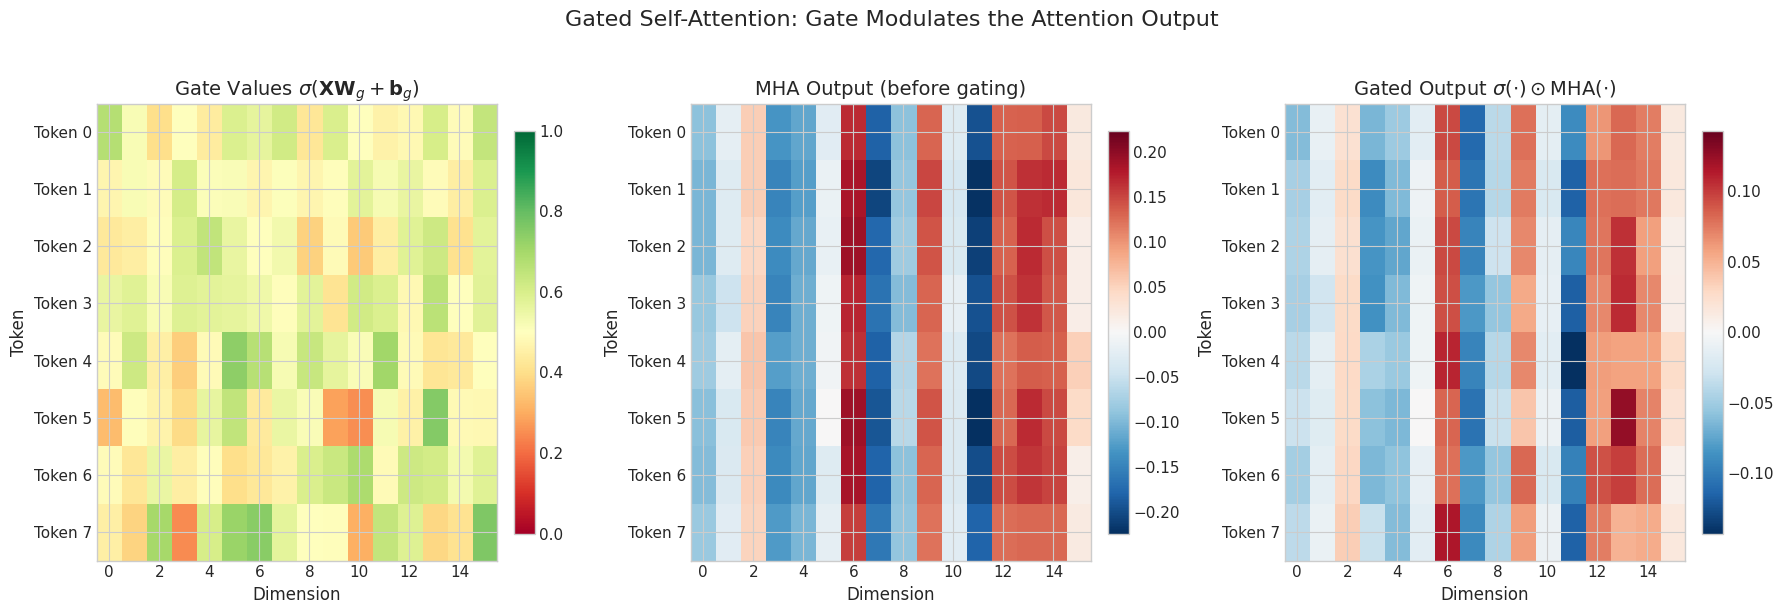

In [11]:
# Visualize: gate values and gating effect
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (a) Gate values heatmap
ax = axes[0]
im0 = ax.imshow(gate_vals, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Dimension')
ax.set_ylabel('Token')
ax.set_yticks(range(n_tokens))
ax.set_yticklabels([f'Token {i}' for i in range(n_tokens)])
ax.set_title('Gate Values $\\sigma(\\mathbf{X}\\mathbf{W}_g + \\mathbf{b}_g)$')
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# (b) MHA output
ax = axes[1]
vmax_mha = np.abs(mha_out).max()
im1 = ax.imshow(mha_out, cmap='RdBu_r', aspect='auto', vmin=-vmax_mha, vmax=vmax_mha)
ax.set_xlabel('Dimension')
ax.set_ylabel('Token')
ax.set_yticks(range(n_tokens))
ax.set_yticklabels([f'Token {i}' for i in range(n_tokens)])
ax.set_title('MHA Output (before gating)')
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# (c) Gated output
ax = axes[2]
vmax_gated = np.abs(gated_out).max()
im2 = ax.imshow(gated_out, cmap='RdBu_r', aspect='auto', vmin=-vmax_gated, vmax=vmax_gated)
ax.set_xlabel('Dimension')
ax.set_ylabel('Token')
ax.set_yticks(range(n_tokens))
ax.set_yticklabels([f'Token {i}' for i in range(n_tokens)])
ax.set_title('Gated Output $\\sigma(\\cdot) \\odot \\mathrm{MHA}(\\cdot)$')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Gated Self-Attention: Gate Modulates the Attention Output', y=1.02)
plt.tight_layout()
plt.show()

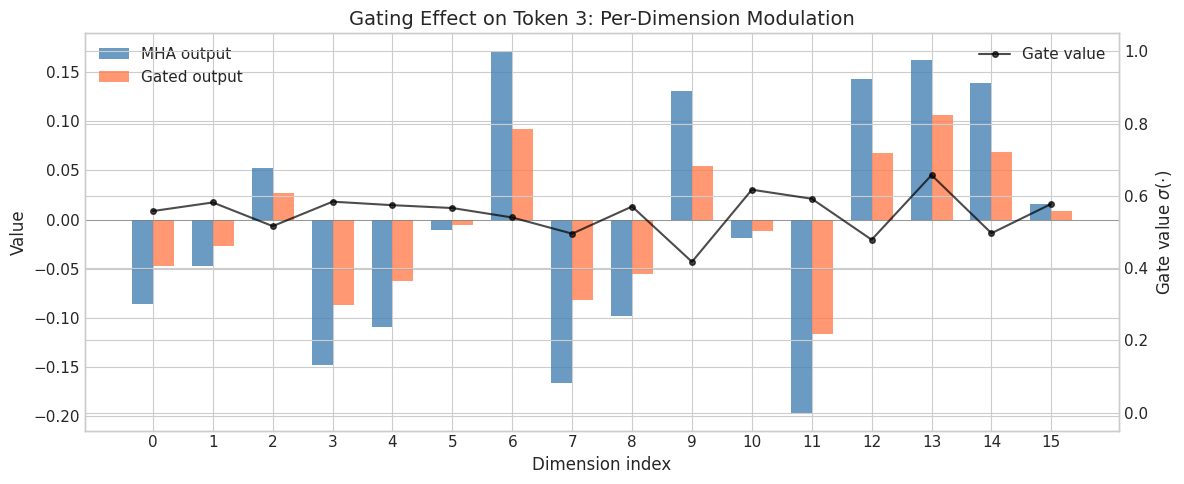

In [12]:
# Show per-dimension effect of gating for one token
token_idx = 3

fig, ax = plt.subplots(figsize=(12, 5))
dims = np.arange(d_model)
width = 0.35

bars1 = ax.bar(dims - width/2, mha_out[token_idx], width, label='MHA output', alpha=0.8, color='steelblue')
bars2 = ax.bar(dims + width/2, gated_out[token_idx], width, label='Gated output', alpha=0.8, color='coral')

# Overlay gate values on secondary axis
ax2 = ax.twinx()
ax2.plot(dims, gate_vals[token_idx], 'k-o', markersize=4, linewidth=1.5, label='Gate value', alpha=0.7)
ax2.set_ylabel('Gate value $\\sigma(\\cdot)$')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right')

ax.set_xlabel('Dimension index')
ax.set_ylabel('Value')
ax.set_title(f'Gating Effect on Token {token_idx}: Per-Dimension Modulation')
ax.set_xticks(dims)
ax.legend(loc='upper left')
ax.axhline(y=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

**Key insight:** The gate values are input-dependent (they are a function of $\mathbf{X}$), meaning the network can learn to suppress certain dimensions of the attention output based on the current input context. Dimensions where the gate is near 0 are effectively silenced, while dimensions where the gate is near 1 pass through unaltered. This provides a learned, soft selection mechanism.

---

## 6. Triangular Self-Attention

The pair representation in AlphaFold2 has shape $(N_{\text{res}}, N_{\text{res}}, c_z)$, where $\mathbf{z}_{ij}$ represents the relationship between residues $i$ and $j$. Triangular self-attention operates on this representation by exploiting the **graph structure** of pairwise interactions.

### "Starting node" triangular attention

For a fixed starting node $i$, we consider all edges $(i, j)$ for $j = 1, \dots, N_{\text{res}}$. The attention is computed over the ending nodes:

$$\text{TriAttn}_{\text{start}}(\mathbf{z}_{ij}) = \sum_{k=1}^{N_{\text{res}}} \alpha_{ijk} \cdot \mathbf{v}_{ik}$$

where the attention weights are:

$$\alpha_{ijk} = \frac{\exp\!\left(\frac{q_{ij}^T k_{ik}}{\sqrt{d_k}} + b_{ijk}\right)}{\sum_{l=1}^{N_{\text{res}}} \exp\!\left(\frac{q_{ij}^T k_{il}}{\sqrt{d_k}} + b_{ijl}\right)}$$

The bias term $b_{ijk} = \text{Linear}(\mathbf{z}_{jk})$ encodes triangle consistency: edge $(i,j)$ attends to edge $(i,k)$, and the bias comes from edge $(j,k)$. This creates a **triangle** of information flow: $(i,j) \to (i,k) \leftarrow (j,k)$.

### "Ending node" triangular attention

Symmetrically, for a fixed ending node $j$, we consider all edges $(i, j)$ and attend over the starting nodes:

$$\text{TriAttn}_{\text{end}}(\mathbf{z}_{ij}) = \sum_{k=1}^{N_{\text{res}}} \beta_{ijk} \cdot \mathbf{v}_{kj}$$

where $\beta_{ijk} \propto \exp\!\left(\frac{q_{ij}^T k_{kj}}{\sqrt{d_k}} + b'_{ijk}\right)$ and $b'_{ijk} = \text{Linear}(\mathbf{z}_{ik})$.

### Why triangles?

In a protein's 3D structure, if residue $i$ is close to $j$ and $j$ is close to $k$, then by the triangle inequality, we gain information about the $(i,k)$ distance. Triangular attention **bakes this constraint into the architecture**, ensuring that the pair representation evolves consistently with the geometry of three-body interactions.

In [13]:
def triangular_self_attention_starting(Z, W_Q, W_K, W_V, w_b):
    """
    Triangular self-attention (starting node variant).
    
    For each starting node i, update edges (i, j) by attending over
    all edges (i, k) for k = 1..N_res, with bias from edge (j, k).
    
    Parameters
    ----------
    Z : ndarray, shape (N_res, N_res, c_z)
        Pair representation.
    W_Q, W_K, W_V : ndarray, shape (c_z, d_k)
    w_b : ndarray, shape (c_z,)
        Linear projection for bias from pair representation.
    
    Returns
    -------
    output : ndarray, shape (N_res, N_res, d_v)
    all_weights : ndarray, shape (N_res, N_res, N_res)
        all_weights[i, j, k] = attention weight alpha_{ijk}
    """
    N_res = Z.shape[0]
    d_k = W_Q.shape[1]
    d_v = W_V.shape[1]
    
    output = np.zeros((N_res, N_res, d_v))
    all_weights = np.zeros((N_res, N_res, N_res))
    
    for i in range(N_res):
        # Queries from edges (i, j): Q[j] = z_{ij} W_Q
        Q_i = Z[i] @ W_Q        # (N_res, d_k) -- one query per j
        # Keys from edges (i, k): K[k] = z_{ik} W_K
        K_i = Z[i] @ W_K        # (N_res, d_k) -- one key per k
        # Values from edges (i, k): V[k] = z_{ik} W_V
        V_i = Z[i] @ W_V        # (N_res, d_v)
        
        # Attention logits: (j, k)
        logits = Q_i @ K_i.T / np.sqrt(d_k)    # (N_res, N_res)
        
        # Pair bias: b_{ijk} = z_{jk} . w_b  for each (j, k)
        bias = Z @ w_b     # (N_res, N_res) -- bias[j, k] = Linear(z_{jk})
        logits = logits + bias
        
        # Softmax over k (key dimension)
        weights = softmax(logits, axis=-1)    # (N_res, N_res)
        
        # Output: weighted sum of values
        output[i] = weights @ V_i              # (N_res, d_v)
        all_weights[i] = weights
    
    return output, all_weights


# --- Synthetic pair representation ---
np.random.seed(99)
N_res_pair = 15
c_z_pair = 16
d_k_tri = 8

# Create pair representation with some structure:
# Simulate a protein where nearby residues have correlated pair features
Z_raw = np.random.randn(N_res_pair, N_res_pair, c_z_pair) * 0.3
# Add distance-dependent signal
for i in range(N_res_pair):
    for j in range(N_res_pair):
        dist = abs(i - j)
        Z_raw[i, j, 0] = np.exp(-dist / 3.0)    # proximity signal
        Z_raw[i, j, 1] = -dist / N_res_pair       # linear distance
# Symmetrize
Z_pair_repr = 0.5 * (Z_raw + Z_raw.transpose(1, 0, 2))

# Projection matrices
W_Q_tri = np.random.randn(c_z_pair, d_k_tri) * 0.15
W_K_tri = np.random.randn(c_z_pair, d_k_tri) * 0.15
W_V_tri = np.random.randn(c_z_pair, d_k_tri) * 0.15
w_b_tri = np.random.randn(c_z_pair) * 0.1

tri_output, tri_weights = triangular_self_attention_starting(
    Z_pair_repr, W_Q_tri, W_K_tri, W_V_tri, w_b_tri
)

print(f'Pair representation shape:   {Z_pair_repr.shape}')
print(f'Triangular attn output:      {tri_output.shape}')
print(f'Triangular attn weights:     {tri_weights.shape}  (i, j, k)')

Pair representation shape:   (15, 15, 16)
Triangular attn output:      (15, 15, 8)
Triangular attn weights:     (15, 15, 15)  (i, j, k)


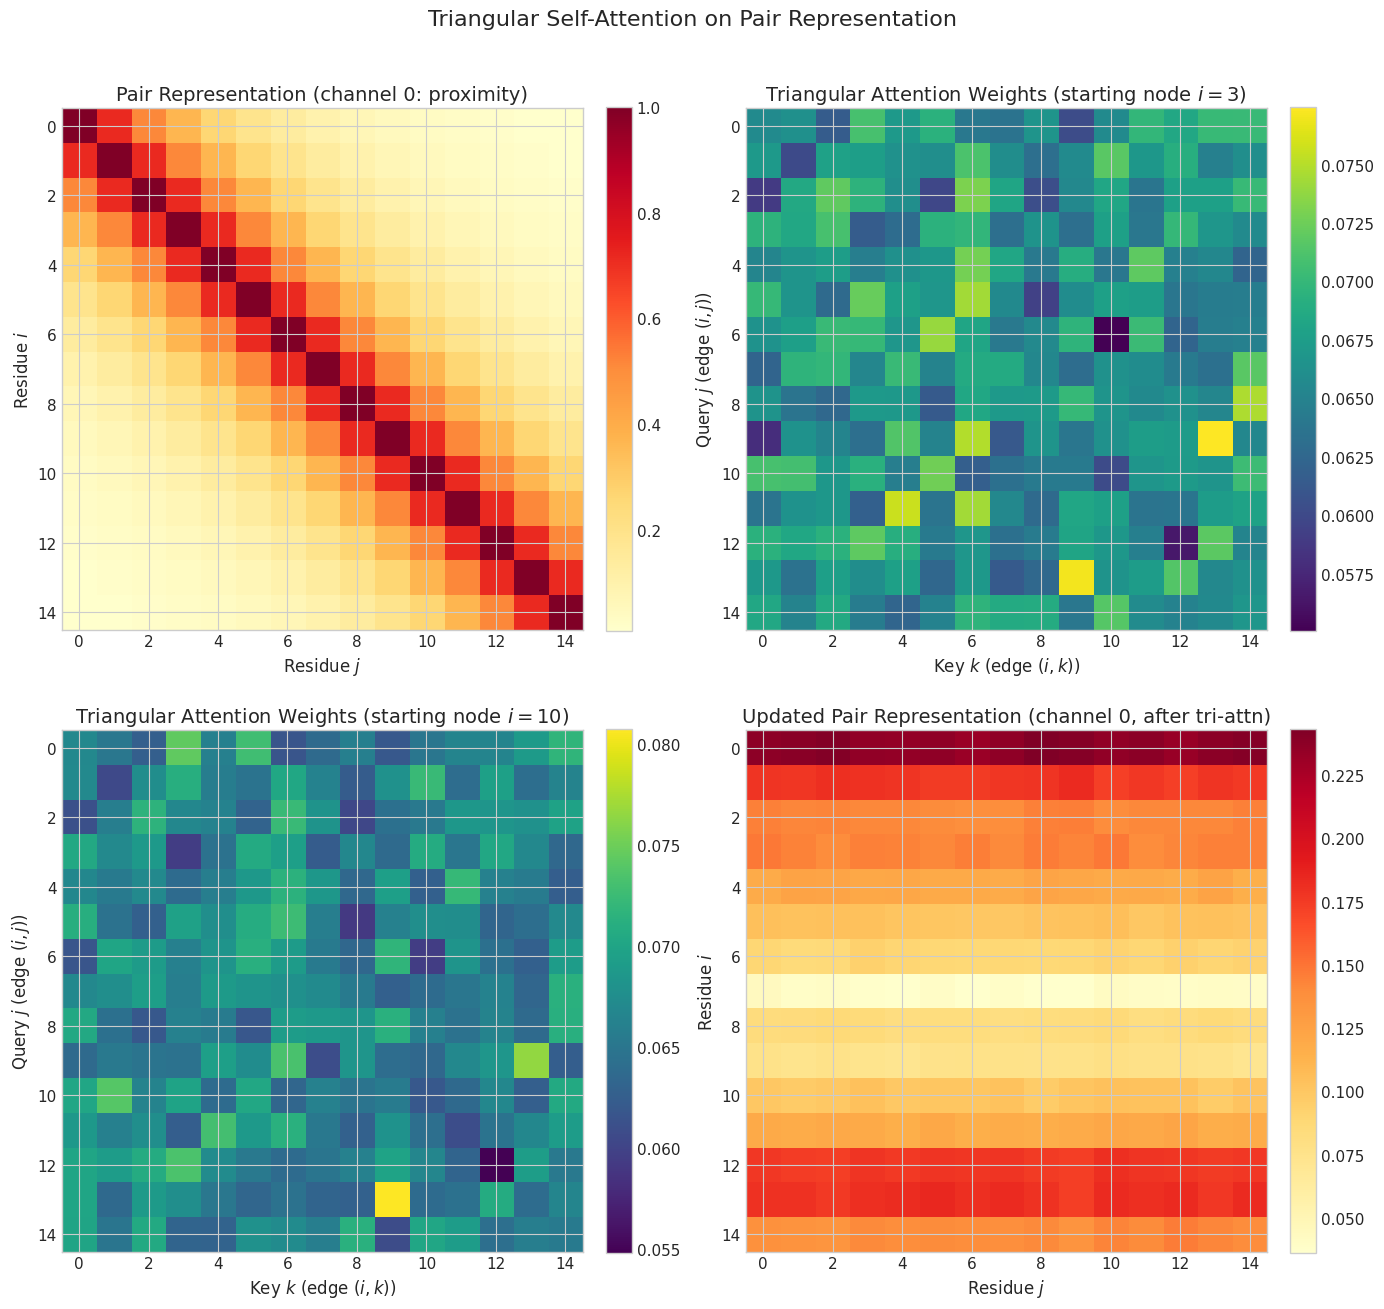

In [14]:
# Visualize: pair matrix, triangular attention pattern, updated pair matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 13))

# (a) Original pair representation (channel 0: proximity signal)
ax = axes[0, 0]
im0 = ax.imshow(Z_pair_repr[:, :, 0], cmap='YlOrRd', aspect='equal')
ax.set_xlabel('Residue $j$')
ax.set_ylabel('Residue $i$')
ax.set_title('Pair Representation (channel 0: proximity)')
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# (b) Triangular attention weights for starting node i=3
ax = axes[0, 1]
node_i = 3
im1 = ax.imshow(tri_weights[node_i], cmap='viridis', aspect='equal')
ax.set_xlabel('Key $k$ (edge $(i, k)$)')
ax.set_ylabel('Query $j$ (edge $(i, j)$)')
ax.set_title(f'Triangular Attention Weights (starting node $i={node_i}$)')
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# (c) Triangular attention weights for starting node i=10
ax = axes[1, 0]
node_i2 = 10
im2 = ax.imshow(tri_weights[node_i2], cmap='viridis', aspect='equal')
ax.set_xlabel('Key $k$ (edge $(i, k)$)')
ax.set_ylabel('Query $j$ (edge $(i, j)$)')
ax.set_title(f'Triangular Attention Weights (starting node $i={node_i2}$)')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (d) Updated pair representation (channel 0)
ax = axes[1, 1]
im3 = ax.imshow(tri_output[:, :, 0], cmap='YlOrRd', aspect='equal')
ax.set_xlabel('Residue $j$')
ax.set_ylabel('Residue $i$')
ax.set_title('Updated Pair Representation (channel 0, after tri-attn)')
fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Triangular Self-Attention on Pair Representation', y=1.01)
plt.tight_layout()
plt.show()

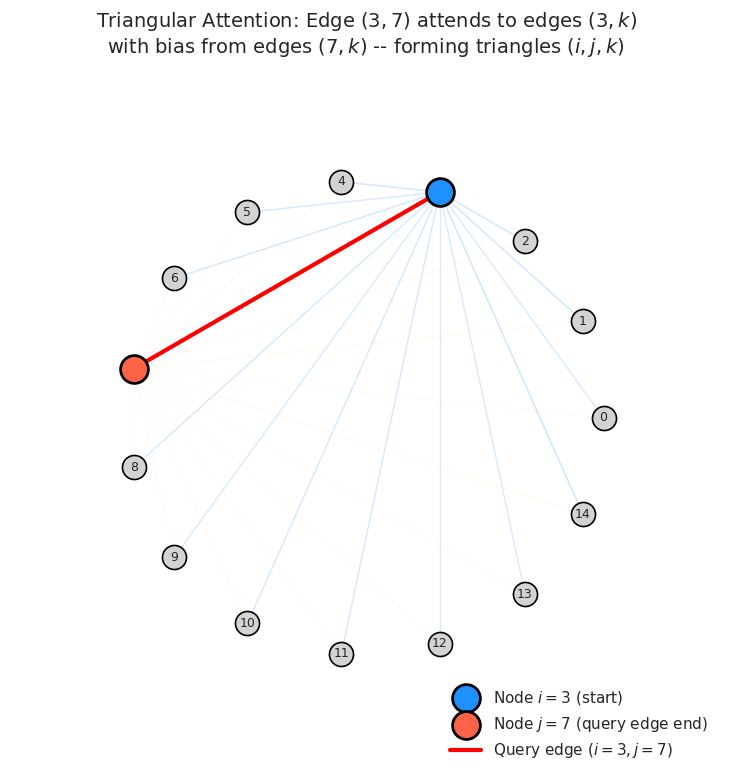

In [15]:
# Visualize the triangular information flow pattern
fig, ax = plt.subplots(figsize=(10, 8))

# Show which pairs attend to which for a specific edge (i=3, j=7)
i_fixed, j_fixed = 3, 7
attn_over_k = tri_weights[i_fixed, j_fixed, :]   # (N_res,)

# Create a schematic: highlight the triangle
# Plot all residues as nodes in a circle
n_show = N_res_pair
theta = np.linspace(0, 2 * np.pi, n_show, endpoint=False)
node_x = np.cos(theta)
node_y = np.sin(theta)

# Draw all nodes
ax.scatter(node_x, node_y, s=300, c='lightgray', edgecolors='black', linewidth=1.2, zorder=5)
for r in range(n_show):
    ax.annotate(f'{r}', (node_x[r], node_y[r]), ha='center', va='center', fontsize=9, zorder=6)

# Highlight node i and j
ax.scatter([node_x[i_fixed]], [node_y[i_fixed]], s=400, c='dodgerblue', edgecolors='black',
           linewidth=2, zorder=7, label=f'Node $i={i_fixed}$ (start)')
ax.scatter([node_x[j_fixed]], [node_y[j_fixed]], s=400, c='tomato', edgecolors='black',
           linewidth=2, zorder=7, label=f'Node $j={j_fixed}$ (query edge end)')

# Draw attention-weighted edges from (i,j) to (i,k) with color intensity
for k in range(n_show):
    w = attn_over_k[k]
    if w > 0.01:   # only draw visible edges
        # Edge (i, k) -- the key edges
        ax.plot([node_x[i_fixed], node_x[k]], [node_y[i_fixed], node_y[k]],
                color='dodgerblue', alpha=float(np.clip(w * 3, 0, 1)),
                linewidth=float(w * 15), zorder=2)
        # Edge (j, k) -- the bias source
        ax.plot([node_x[j_fixed], node_x[k]], [node_y[j_fixed], node_y[k]],
                color='orange', alpha=float(np.clip(w * 2, 0, 0.6)),
                linewidth=float(w * 8), linestyle='--', zorder=1)

# The query edge (i, j)
ax.plot([node_x[i_fixed], node_x[j_fixed]], [node_y[i_fixed], node_y[j_fixed]],
        color='red', linewidth=3, zorder=3, label=f'Query edge $(i={i_fixed}, j={j_fixed})$')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend(loc='lower right', framealpha=0.9)
ax.set_title(f'Triangular Attention: Edge $({i_fixed},{j_fixed})$ attends to edges $({i_fixed}, k)$\n'
             f'with bias from edges $({j_fixed}, k)$ -- forming triangles $(i,j,k)$')
ax.grid(False)
ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretation of the triangle diagram:**

- The **red edge** $(i, j)$ is the query edge being updated.
- **Blue edges** $(i, k)$ are the key/value edges that are attended over, with line thickness proportional to the attention weight.
- **Orange dashed edges** $(j, k)$ provide the triangular bias: the information from edge $(j, k)$ biases whether edge $(i, j)$ should attend to edge $(i, k)$.
- This creates a **triangle** $(i, j, k)$ at each attention step, enforcing geometric consistency: if edges $(i,j)$ and $(i,k)$ both have strong representations, and edge $(j,k)$ supports their relationship, the attention weight increases.

This mechanism is central to AlphaFold2's ability to reason about pairwise distances in a manner consistent with 3D geometry.

---

## 7. Computational Complexity Comparison

A key design principle in AlphaFold2 is managing computational complexity while maintaining expressivity. Let us compare the attention mechanisms:

| Mechanism | Representation | Attention Over | Complexity (per layer) |
|-----------|---------------|----------------|------------------------|
| Standard self-attention (full MSA) | $(N_s \cdot N_r, c)$ | All positions | $O(N_s^2 \cdot N_r^2 \cdot c)$ |
| Row attention | $(N_s, N_r, c)$ | Residues per sequence | $O(N_s \cdot N_r^2 \cdot c)$ |
| Column attention | $(N_s, N_r, c)$ | Sequences per position | $O(N_s^2 \cdot N_r \cdot c)$ |
| Triangular attention | $(N_r, N_r, c)$ | Pair edges | $O(N_r^3 \cdot c)$ |

Where $N_s = N_{\text{seq}}$, $N_r = N_{\text{res}}$, and $c$ is the channel dimension.

The axial decomposition (row + column) replaces $O(N_s^2 N_r^2)$ with $O(N_s N_r^2 + N_s^2 N_r) = O(N_s N_r \cdot \max(N_s, N_r))$, which is a substantial saving when both $N_s$ and $N_r$ are large.

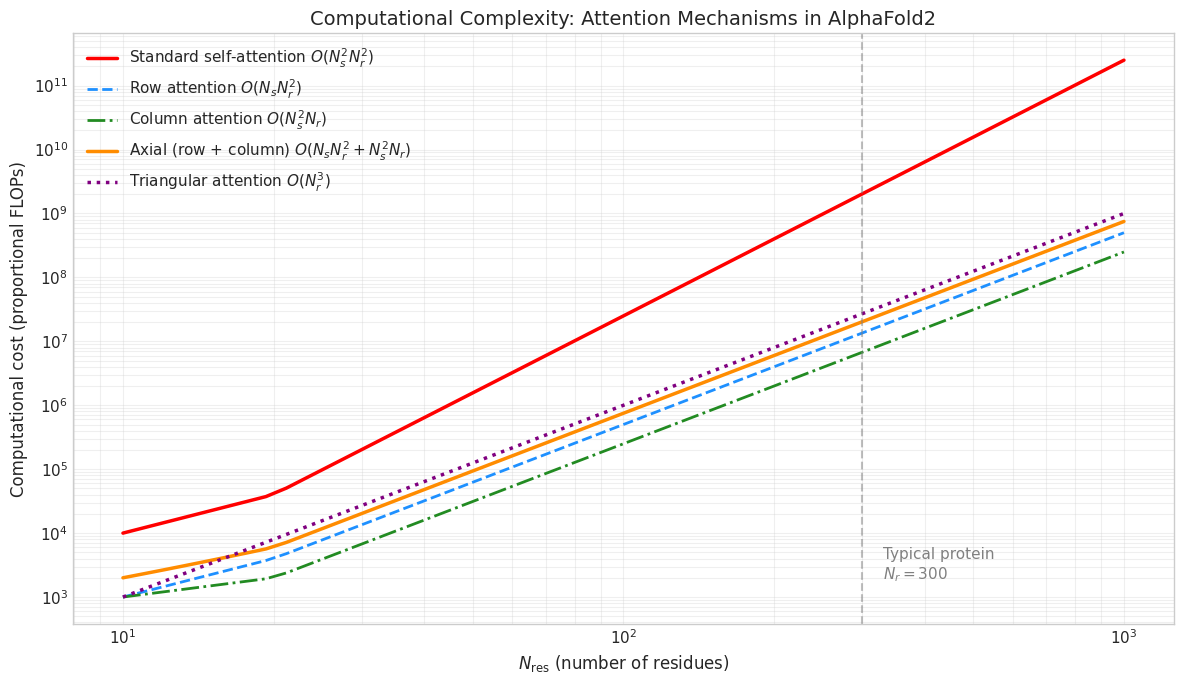

In [16]:
# Computational cost comparison: log-log plot
L = np.logspace(1, 3, 50)   # sequence length from 10 to 1000
c = 128                      # channel dimension (constant)
N_s_ratio = 0.5              # assume N_seq ~ 0.5 * N_res for illustration

N_r = L
N_s = np.maximum(N_s_ratio * L, 10)   # at least 10 sequences

# Compute FLOPs (proportional to; dropping constant c factor for clarity)
cost_standard = N_s**2 * N_r**2      # O(N_s^2 * N_r^2)
cost_row = N_s * N_r**2              # O(N_s * N_r^2)
cost_column = N_s**2 * N_r           # O(N_s^2 * N_r)
cost_axial = cost_row + cost_column  # Row + Column combined
cost_triangular = N_r**3             # O(N_r^3)

fig, ax = plt.subplots(figsize=(12, 7))

ax.loglog(L, cost_standard, '-', linewidth=2.5, color='red', label='Standard self-attention $O(N_s^2 N_r^2)$')
ax.loglog(L, cost_row, '--', linewidth=2, color='dodgerblue', label='Row attention $O(N_s N_r^2)$')
ax.loglog(L, cost_column, '-.', linewidth=2, color='forestgreen', label='Column attention $O(N_s^2 N_r)$')
ax.loglog(L, cost_axial, '-', linewidth=2.5, color='darkorange', label='Axial (row + column) $O(N_s N_r^2 + N_s^2 N_r)$')
ax.loglog(L, cost_triangular, ':', linewidth=2.5, color='purple', label='Triangular attention $O(N_r^3)$')

# Mark a typical protein length
typical_L = 300
ax.axvline(x=typical_L, color='gray', linestyle='--', alpha=0.5)
ax.text(typical_L * 1.1, ax.get_ylim()[0] * 5, f'Typical protein\n$N_r = {typical_L}$',
        fontsize=11, color='gray')

ax.set_xlabel('$N_{\\mathrm{res}}$ (number of residues)')
ax.set_ylabel('Computational cost (proportional FLOPs)')
ax.set_title('Computational Complexity: Attention Mechanisms in AlphaFold2')
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Compute the savings factor at the typical protein length
N_r_typ = 300
N_s_typ = max(150, 10)

standard = N_s_typ**2 * N_r_typ**2
axial = N_s_typ * N_r_typ**2 + N_s_typ**2 * N_r_typ
savings = standard / axial

print(f'At N_res = {N_r_typ}, N_seq = {N_s_typ}:')
print(f'  Standard self-attention:  {standard:.2e} FLOPs (proportional)')
print(f'  Axial (row + column):     {axial:.2e} FLOPs (proportional)')
print(f'  Savings factor:           {savings:.1f}x')
print(f'\nBreakdown:')
print(f'  Row attention:    {N_s_typ * N_r_typ**2:.2e}')
print(f'  Column attention: {N_s_typ**2 * N_r_typ:.2e}')
print(f'  Triangular:       {N_r_typ**3:.2e}')

At N_res = 300, N_seq = 150:
  Standard self-attention:  2.02e+09 FLOPs (proportional)
  Axial (row + column):     2.02e+07 FLOPs (proportional)
  Savings factor:           100.0x

Breakdown:
  Row attention:    1.35e+07
  Column attention: 6.75e+06
  Triangular:       2.70e+07


**Summary of computational analysis:**

For a typical protein with $N_{\text{res}} = 300$ and $N_{\text{seq}} = 150$:

- Standard self-attention on the flattened MSA would require $O(N_s^2 N_r^2) \approx 2 \times 10^{9}$ operations.
- The axial decomposition (row + column) requires only $O(N_s N_r^2 + N_s^2 N_r) \approx 2 \times 10^{7}$, a savings of roughly **100x**.
- Triangular attention on the pair representation scales as $O(N_r^3) = 2.7 \times 10^{7}$, which is manageable but becomes the bottleneck for very long sequences.

This factored attention design is what makes AlphaFold2 tractable for proteins up to thousands of residues.

---

## 8. Summary and Key Takeaways

This notebook built every attention mechanism in AlphaFold2 from first principles. Here are the essential points:

### The attention toolkit of AlphaFold2

| Mechanism | Where | Purpose |
|-----------|-------|---------|
| **Self-attention** | Foundation | Standard query-key-value mechanism |
| **Multi-head attention** | Everywhere | Parallel attention subspaces |
| **Row attention** (with pair bias) | MSA stack | Residue-residue communication within each sequence, guided by pair representation |
| **Column attention** | MSA stack | Sequence-sequence communication at each position (coevolution) |
| **Gated attention** | MSA + pair stacks | Input-dependent modulation of attention output |
| **Triangular self-attention** | Pair stack | Edge-edge communication enforcing geometric triangle consistency |

### Key design principles

1. **Axial decomposition:** By factoring full 2D attention into independent row and column operations, AlphaFold2 reduces complexity from $O(N_s^2 N_r^2)$ to $O(N_s N_r \max(N_s, N_r))$ while still allowing information to flow along both axes.

2. **Cross-representation communication:** The pair bias in row attention creates a **bridge** between the MSA representation and the pair representation, allowing structural information to inform sequence-level attention patterns.

3. **Geometric inductive bias:** Triangular attention encodes the fundamental constraint that pairwise distances in 3D space must satisfy the triangle inequality. This is not just a heuristic -- it is a structural prior that dramatically improves the quality of predicted distance maps.

4. **Gating for stability:** Element-wise gating provides fine-grained control over information flow, improving training stability in the deep Evoformer stack (typically 48 layers).

### Preview: Notebook 5 -- The Evoformer

In the next notebook, we will see how all of these attention mechanisms are composed into the **Evoformer block**, the core processing unit of AlphaFold2. The Evoformer alternates between:

- MSA processing (row attention $\to$ column attention $\to$ transition)
- Pair processing (triangular attention $\to$ triangular multiplicative updates $\to$ transition)
- Outer product mean (MSA $\to$ pair communication)

This creates a powerful iterative refinement loop where sequence information and structural information continuously enrich each other.

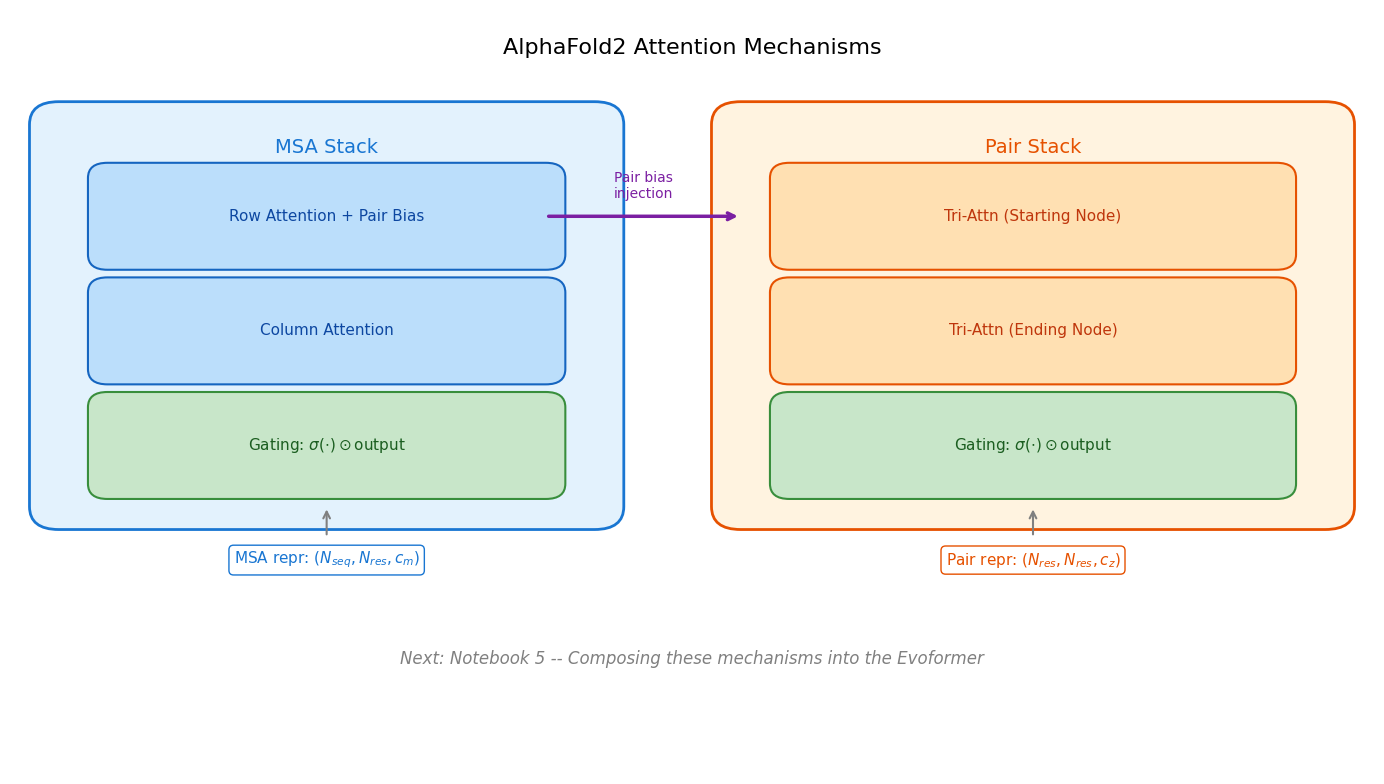

In [18]:
# Final summary visualization: architecture of attention mechanisms
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# --- Draw schematic boxes for each attention type ---
import matplotlib.patches as patches

box_style = dict(boxstyle='round,pad=0.4', edgecolor='black', linewidth=1.5)

# Title
ax.text(7, 9.5, 'AlphaFold2 Attention Mechanisms', ha='center', va='center',
        fontsize=16, color='black')

# MSA Stack
msa_box = patches.FancyBboxPatch((0.5, 3.5), 5.5, 5, boxstyle='round,pad=0.3',
                                  facecolor='#E3F2FD', edgecolor='#1976D2', linewidth=2)
ax.add_patch(msa_box)
ax.text(3.25, 8.2, 'MSA Stack', ha='center', va='center', fontsize=14, color='#1976D2')

# Row attention
row_box = patches.FancyBboxPatch((1, 6.8), 4.5, 1.0, boxstyle='round,pad=0.2',
                                  facecolor='#BBDEFB', edgecolor='#1565C0', linewidth=1.5)
ax.add_patch(row_box)
ax.text(3.25, 7.3, 'Row Attention + Pair Bias', ha='center', va='center', fontsize=11, color='#0D47A1')

# Column attention
col_box = patches.FancyBboxPatch((1, 5.3), 4.5, 1.0, boxstyle='round,pad=0.2',
                                  facecolor='#BBDEFB', edgecolor='#1565C0', linewidth=1.5)
ax.add_patch(col_box)
ax.text(3.25, 5.8, 'Column Attention', ha='center', va='center', fontsize=11, color='#0D47A1')

# Gated (spanning MSA components)
gate_box = patches.FancyBboxPatch((1, 3.8), 4.5, 1.0, boxstyle='round,pad=0.2',
                                   facecolor='#C8E6C9', edgecolor='#388E3C', linewidth=1.5)
ax.add_patch(gate_box)
ax.text(3.25, 4.3, 'Gating: $\\sigma(\\cdot) \\odot \\mathrm{output}$', ha='center', va='center',
        fontsize=11, color='#1B5E20')

# Pair Stack
pair_box = patches.FancyBboxPatch((7.5, 3.5), 6, 5, boxstyle='round,pad=0.3',
                                   facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
ax.add_patch(pair_box)
ax.text(10.5, 8.2, 'Pair Stack', ha='center', va='center', fontsize=14, color='#E65100')

# Triangular start
tri_start_box = patches.FancyBboxPatch((8, 6.8), 5, 1.0, boxstyle='round,pad=0.2',
                                        facecolor='#FFE0B2', edgecolor='#E65100', linewidth=1.5)
ax.add_patch(tri_start_box)
ax.text(10.5, 7.3, 'Tri-Attn (Starting Node)', ha='center', va='center',
        fontsize=11, color='#BF360C')

# Triangular end
tri_end_box = patches.FancyBboxPatch((8, 5.3), 5, 1.0, boxstyle='round,pad=0.2',
                                      facecolor='#FFE0B2', edgecolor='#E65100', linewidth=1.5)
ax.add_patch(tri_end_box)
ax.text(10.5, 5.8, 'Tri-Attn (Ending Node)', ha='center', va='center',
        fontsize=11, color='#BF360C')

# Gating for pair stack
gate_pair_box = patches.FancyBboxPatch((8, 3.8), 5, 1.0, boxstyle='round,pad=0.2',
                                        facecolor='#C8E6C9', edgecolor='#388E3C', linewidth=1.5)
ax.add_patch(gate_pair_box)
ax.text(10.5, 4.3, 'Gating: $\\sigma(\\cdot) \\odot \\mathrm{output}$', ha='center', va='center',
        fontsize=11, color='#1B5E20')

# Cross-communication arrow
ax.annotate('', xy=(7.5, 7.3), xytext=(5.5, 7.3),
            arrowprops=dict(arrowstyle='->', color='#7B1FA2', lw=2.5))
ax.text(6.5, 7.7, 'Pair bias\ninjection', ha='center', va='center', fontsize=10, color='#7B1FA2')

# Input / Output labels
ax.text(3.25, 2.8, 'MSA repr: $(N_{seq}, N_{res}, c_m)$', ha='center', va='center',
        fontsize=11, color='#1976D2',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#1976D2'))

ax.text(10.5, 2.8, 'Pair repr: $(N_{res}, N_{res}, c_z)$', ha='center', va='center',
        fontsize=11, color='#E65100',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#E65100'))

# Arrows from labels to boxes
ax.annotate('', xy=(3.25, 3.5), xytext=(3.25, 3.1),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xy=(10.5, 3.5), xytext=(10.5, 3.1),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Bottom note
ax.text(7, 1.5, 'Next: Notebook 5 -- Composing these mechanisms into the Evoformer',
        ha='center', va='center', fontsize=12, color='gray', style='italic')

plt.tight_layout()
plt.show()